<a href="https://colab.research.google.com/github/SvitlanaSm/Python-Sales-Analysis/blob/main/Sales_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Data overview

In [ ]:
# Changing work folder
%cd /content/drive/MyDrive/mate/colab/data_loading

[Errno 2] No such file or directory: '/content/drive/MyDrive/mate/colab/data_loading'
/content


In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/mate/colab/data_loading/final_project

# Uploading dataset
events = pd.read_csv("events.csv")
events.columns = events.columns.str.lower().str.replace(" ", "_")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")
print(events.head())
print(products.head())
print(countries.head())

Mounted at /content/drive
/content/drive/MyDrive/mate/colab/data_loading/final_project
    order_id order_date   ship_date order_priority country_code  product_id  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  sales_channel  units_sold  unit_price  unit_cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Bever

Таблиця **"events"** містить такі колонки:  

*order_id* - ідентифікатор замовлення  
*order_date* - дата замовлення  
*ship_date* - дата відсправлення  
*order_priority* - пріоритет замовлення  
*country_code* - код країни  
*product_id* - ідентифікатор товару  
*sales_channel* - канал з якого було зроблене замовлення  
*units_sold* - сума проданих одиниць  
*unit_price* - ціна продажу одиниці товару  
*unit_cost* - вартість одиниці товару

Таблиця **"products"** містить такі колонки:  

*id* - ідентифікатор товару    
*item_type* - тип товару  

Таблиця **"countries"** містить такі колонки:  

*name* - назва країни  
*alpha-2* - код країни з 2 літер  
*alpha-3* - код країни з 3 літер  
*region* - регіон де розташована країна  
*sub-region* - субрегіон де розташована країна

Таблиці **"events" та "products"** об'єднуються колонками "product_id" та "id" відповідно.  
А таблиці **"events" та "countries"** об'єднуються "country_code" та "alpha-3" відповідно.

#2. Data cleaning

In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1330 non-null   int64  
 1   order_date      1330 non-null   object 
 2   ship_date       1330 non-null   object 
 3   order_priority  1330 non-null   object 
 4   country_code    1248 non-null   object 
 5   product_id      1330 non-null   int64  
 6   sales_channel   1330 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1330 non-null   float64
 9   unit_cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
# Persent of omitted values in "events"
print(events.isna().sum() / events.shape[0] * 100)

order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64


У таблиці "events" є пропущені значення у колонці **"country_code"** (6,16%) та у колонці **"units_sold"** (0,15%).

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
# Persent of omitted values in "products"
print(products.isna().sum() / products.shape[0] * 100)

id           0.0
item_type    0.0
dtype: float64


У таблиці "products" **немає** пропущених значень.

In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
# Persent of omitted values in "countries"
print(countries.isna().sum() / countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


У таблиці "countries" є пропущені значення у колонках **"alpha-2", "region", "sub-region"** доля яких 0,4%.

In [ ]:
# Delete rows that contain at least one omitted value
events.dropna()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
5,103450715,3/15/2015,4/18/2015,H,SVK,8681,Online,2220.0,651.21,524.96
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


Видалили всі рядки як мають пусті значення. Адже "country_code" не можливо замінити, а "units_sold" має долю пропущених значень 0,15%. Отжу, можемо видалити ті рядки, які мають пропущені значення.

In [ ]:
# delete rows that contain at least one omitted value
countries.dropna()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


Аналогічна причина видалення до попереднього, всього 0,4% пропущених.

In [ ]:
# Make correct type of data in "events"
events["order_date"] = pd.to_datetime(events["order_date"])
events["ship_date"] = pd.to_datetime(events["ship_date"])
events["order_id"] = events["order_id"].astype(object)
events["product_id"] = events["product_id"].astype(object)
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   object        
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1248 non-null   object        
 5   product_id      1330 non-null   object        
 6   sales_channel   1330 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 104.0+ KB


In [ ]:
# Make correct type of data in "products"
products["id"] = products["id"].astype(object)

In [ ]:
# Number of duplicates
print(f"Number of duplicates in events: {events.duplicated().sum()}")
print(f"Number of duplicates in products: {products.duplicated().sum()}")
print(f"Number of duplicates in countries: {countries.duplicated().sum()}")

Number of duplicates in events: 0
Number of duplicates in products: 0
Number of duplicates in countries: 0


In [ ]:
events.describe()

,order_date,ship_date,units_sold,unit_price,unit_cost
count,1330,1330,1328.000000,1330.000000,1330.000000
mean,2013-10-12 06:09:12.180451072,2013-11-06 00:46:33.383458816,4952.201807,264.893541,187.246812
min,2010-01-01 00:00:00,2010-01-10 00:00:00,2.000000,9.330000,6.920000
25%,2011-12-16 06:00:00,2012-01-03 00:00:00,2356.750000,81.730000,35.840000
50%,2013-10-17 00:00:00,2013-11-09 00:00:00,4962.000000,154.060000,97.440000
75%,2015-08-28 18:00:00,2015-10-03 18:00:00,7459.500000,437.200000,263.330000
max,2017-07-23 00:00:00,2017-08-31 00:00:00,9999.000000,668.270000,524.960000
std,NaN,NaN,2905.198996,217.323460,176.158873


Колонка **units_sold** не має анамолій.  
**unit_price** та **unit_cost** - мають медіану меншу за середнє значення, що може свідчити про те, що в колонках велика кількість низьких значень. Тобто у компанії більше товарів з низькими ціками


#3. Data analysis and visualization

In [ ]:
# Join tables "events", "products", "countries"
df = events.merge(products, left_on="product_id", right_on="id", how = "left")
df = df.merge(countries, left_on="country_code", right_on="alpha-3", how = "left")
df = df.drop(columns=["id", "country_code"])
df = df.rename(columns={"name": "country", "alpha-2": "country_code_2", "alpha-3": "country_code_3"})
df.head()

,order_id,order_date,ship_date,order_priority,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country,country_code_2,country_code_3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,2103,Online,650.0,205.70,117.11,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Add columns "revenue", "cost", "profit"
df["revenue"] = df["units_sold"]*df["unit_price"]
df["cost"] = df["units_sold"]*df["unit_cost"]
df["profit"] = df["revenue"]-df["cost"]
print(df.head())

    order_id order_date  ship_date order_priority product_id sales_channel  \
0  100640618 2014-10-08 2014-10-18              M       2103        Online   
1  100983083 2016-08-11 2016-08-11              C       2103       Offline   
2  101025998 2014-07-18 2014-08-11              M       7940        Online   
3  102230632 2017-05-13 2017-06-13              L       2455        Online   
4  103435266 2012-08-11 2012-09-18              H       1270       Offline   

   units_sold  unit_price  unit_cost  item_type     country country_code_2  \
0       650.0      205.70     117.11     Cereal      Norway             NO   
1      1993.0      205.70     117.11     Cereal      Serbia             RS   
2      4693.0      668.27     502.54  Household         NaN            NaN   
3      1171.0      109.28      35.84    Clothes  Montenegro             ME   
4      7648.0       47.45      31.79  Beverages      Serbia             RS   

  country_code_3  region       sub-region     revenue        c

In [ ]:
# Main metrics
print(f"Number of orders: {df.shape[0]}")
print(f"Total profit: {df['profit'].sum()}")
print(f"Number of countries: {df['country'].nunique()}")
print(f"Total units sold: {df['units_sold'].sum()}")
print(f"Number of item type:{df['item_type'].nunique()}")

Number of orders: 1330
Total profit: 501434459.0
Number of countries: 45
Total units sold: 6576524.0
Number of item type:12


In [ ]:
item_types = df["item_type"].unique()
print(item_types)

['Cereal' 'Household' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits'
 'Vegetables' 'Baby Food' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']


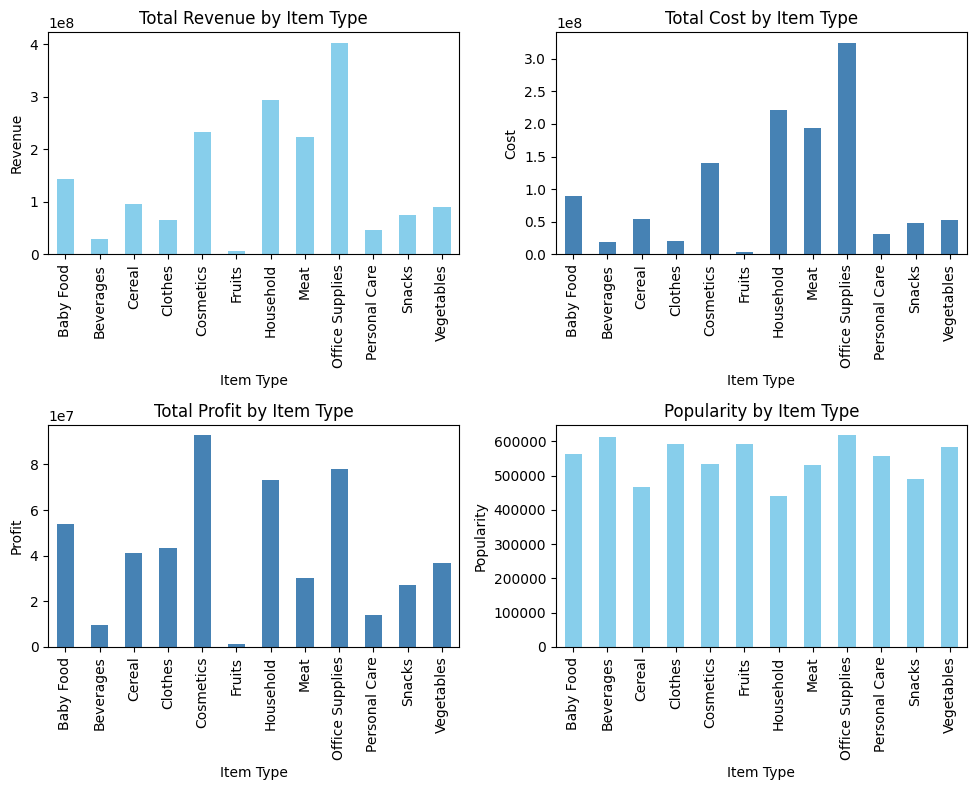

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# First subplot - Bar plot of total revenue by item type
df.groupby("item_type")["revenue"].sum().plot(kind="bar", ax=ax[0, 0], color="skyblue")
ax[0, 0].set_title("Total Revenue by Item Type")  # Title of the subplot
ax[0, 0].set_xlabel("Item Type")  # X-axis label
ax[0, 0].set_ylabel("Revenue")  # Y-axis label

# Second subplot - Bar plot of total cost by item type
df.groupby("item_type")["cost"].sum().plot(kind="bar", ax=ax[0, 1], color="steelblue")
ax[0, 1].set_title("Total Cost by Item Type")  # Title of the subplot
ax[0, 1].set_xlabel("Item Type")  # X-axis label
ax[0, 1].set_ylabel("Cost")  # Y-axis label

# Third subplot - Bar plot of total profit by item type
df.groupby("item_type")["profit"].sum().plot(kind="bar", ax=ax[1, 0], color="steelblue")
ax[1, 0].set_title("Total Profit by Item Type")  # Title of the subplot
ax[1, 0].set_xlabel("Item Type")  # X-axis label
ax[1, 0].set_ylabel("Profit")  # Y-axis label

# Fourth subplot - Bar plot of popularity by item type
df.groupby("item_type")["units_sold"].sum().plot(kind="bar", ax=ax[1, 1], color="skyblue")
ax[1, 1].set_title("Popularity by Item Type")  # Title of the subplot
ax[1, 1].set_xlabel("Item Type")  # X-axis label
ax[1, 1].set_ylabel("Popularity")  # Y-axis label

plt.tight_layout()
plt.show()

**Найнищі** показники по revenue, cost та profit мають категорії товарів *Fruits, Beverages, Personal Care*. Хоча це є одні з найпопулярніших категорій по продажам.  
**Найнищі** показники по revenue, cost має категорія *Office Supplies*, а по profit - *Cosmetics*.  

Тобто, можна зробити висновок, що краще більше продавати товарів *Cosmetics*, адже вони приносять найбільший прибуток та рівень популярності досить високий.

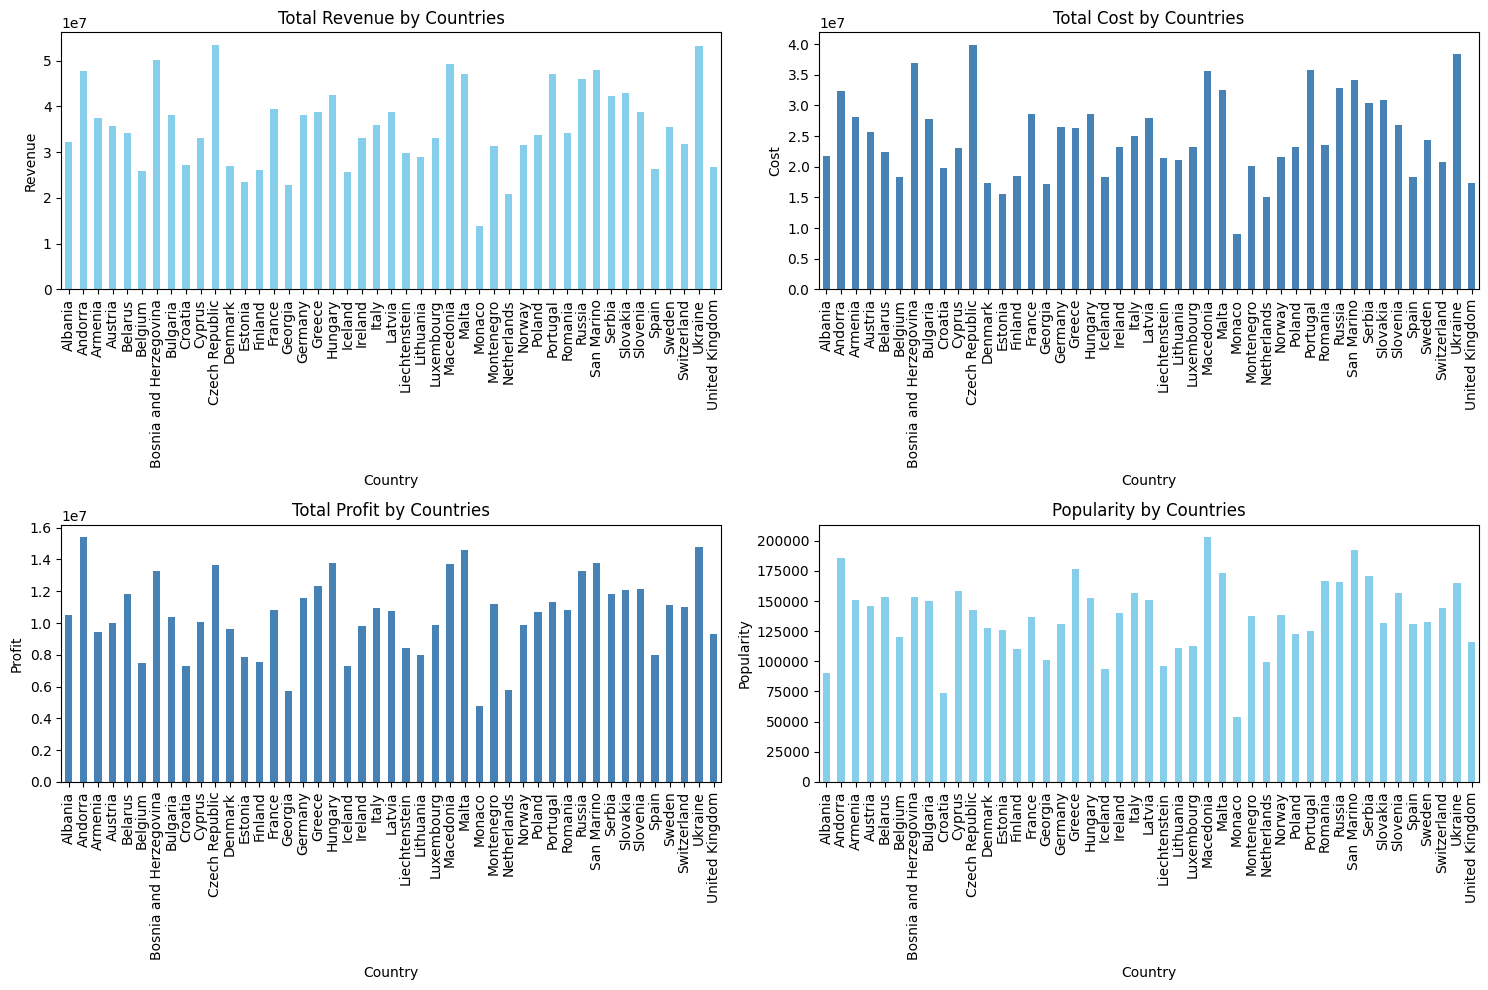

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# First subplot - Bar plot of total revenue by countries
df.groupby("country")["revenue"].sum().plot(kind="bar", ax=ax[0, 0], color="skyblue")
ax[0, 0].set_title("Total Revenue by Countries")  # Title of the subplot
ax[0, 0].set_xlabel("Country")  # X-axis label
ax[0, 0].set_ylabel("Revenue")  # Y-axis label

# Second subplot - Bar plot of total cost by countries
df.groupby("country")["cost"].sum().plot(kind="bar", ax=ax[0, 1], color="steelblue")
ax[0, 1].set_title("Total Cost by Countries")  # Title of the subplot
ax[0, 1].set_xlabel("Country")  # X-axis label
ax[0, 1].set_ylabel("Cost")  # Y-axis label

# Third subplot - Bar plot of total profit by countries
df.groupby("country")["profit"].sum().plot(kind="bar", ax=ax[1, 0], color="steelblue")
ax[1, 0].set_title("Total Profit by Countries")  # Title of the subplot
ax[1, 0].set_xlabel("Country")  # X-axis label
ax[1, 0].set_ylabel("Profit")  # Y-axis label

# Fourth subplot - Bar plot of popularity by countries
df.groupby("country")["units_sold"].sum().plot(kind="bar", ax=ax[1, 1], color="skyblue")
ax[1, 1].set_title("Popularity by Countries")  # Title of the subplot
ax[1, 1].set_xlabel("Country")  # X-axis label
ax[1, 1].set_ylabel("Popularity")  # Y-axis label

plt.tight_layout()
plt.show()

Показники **revenue** та **cost**:
* найвищі значення мають країни Ukraine та Czech Republic
* найнищі - Monaco

Показник **profit**:
* найвищі значення мають країни Andorra та Ukraine
* найнищі - Monaco

Показник **popularity**:
* найвищі значення має країна Macedonia
* найнищі - Monaco

Тобто, потрібно звернути увагу на країни з низькими показниками (Monaco), щоб покращити ситуацію по продажам та прибутку.

In [ ]:
# Make correct data in column "sales_channel"
df["sales_channel"] = df["sales_channel"].str.replace("online", "Online")

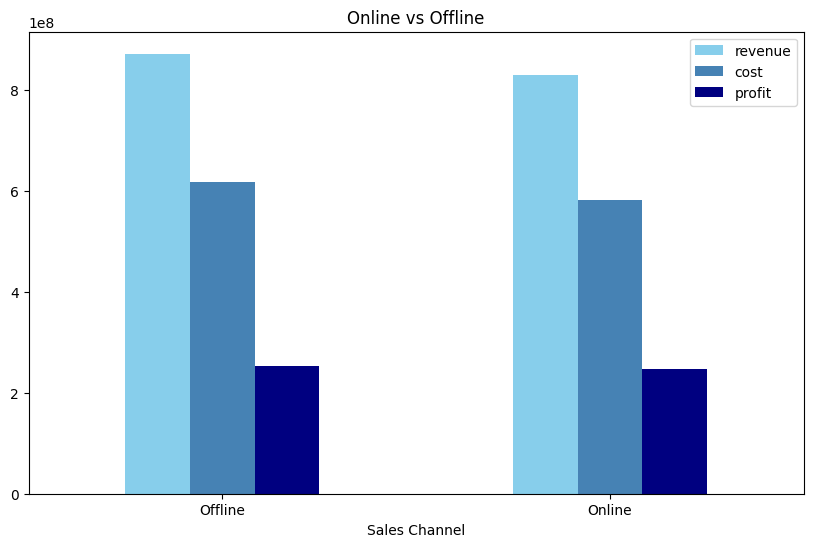

In [ ]:
# Sales by sales channel
channel_summary = df.groupby('sales_channel')[['revenue', 'cost', 'profit']].sum()
channel_summary.plot(kind='bar', figsize=(10,6), title="Online vs Offline", color=['skyblue','steelblue','navy'])

plt.xlabel("Sales Channel")
plt.xticks(rotation=0)
plt.show()

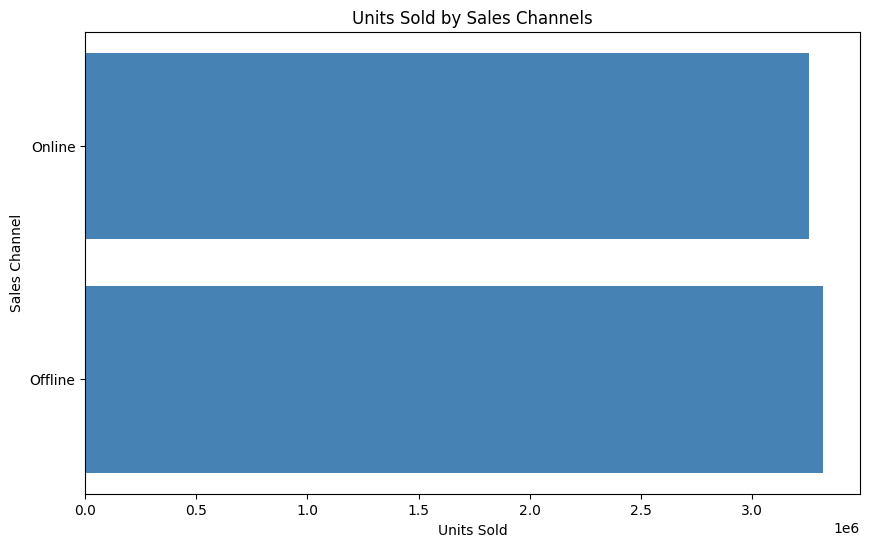

In [ ]:
# Units sold by sales channel
channel_popularity = df.groupby('sales_channel')['units_sold'].sum()

plt.figure(figsize=(10, 6))
bars = plt.barh(channel_popularity.index, channel_popularity.values, color="steelblue")
plt.title("Units Sold by Sales Channels")
plt.xlabel("Units Sold")
plt.ylabel("Sales Channel")

plt.show()

Показники майже однакові як по онлайн каналу продажу, так і по офлайн. Тому на обидва канали варто звертати увагу.

In [ ]:
# Create column "aging"
df["aging"] = (df['ship_date'] - df['order_date']).dt.days
print(df.head())

    order_id order_date  ship_date order_priority product_id sales_channel  \
0  100640618 2014-10-08 2014-10-18              M       2103        Online   
1  100983083 2016-08-11 2016-08-11              C       2103       Offline   
2  101025998 2014-07-18 2014-08-11              M       7940        Online   
3  102230632 2017-05-13 2017-06-13              L       2455        Online   
4  103435266 2012-08-11 2012-09-18              H       1270       Offline   

   units_sold  unit_price  unit_cost  item_type     country country_code_2  \
0       650.0      205.70     117.11     Cereal      Norway             NO   
1      1993.0      205.70     117.11     Cereal      Serbia             RS   
2      4693.0      668.27     502.54  Household         NaN            NaN   
3      1171.0      109.28      35.84    Clothes  Montenegro             ME   
4      7648.0       47.45      31.79  Beverages      Serbia             RS   

  country_code_3  region       sub-region     revenue        c

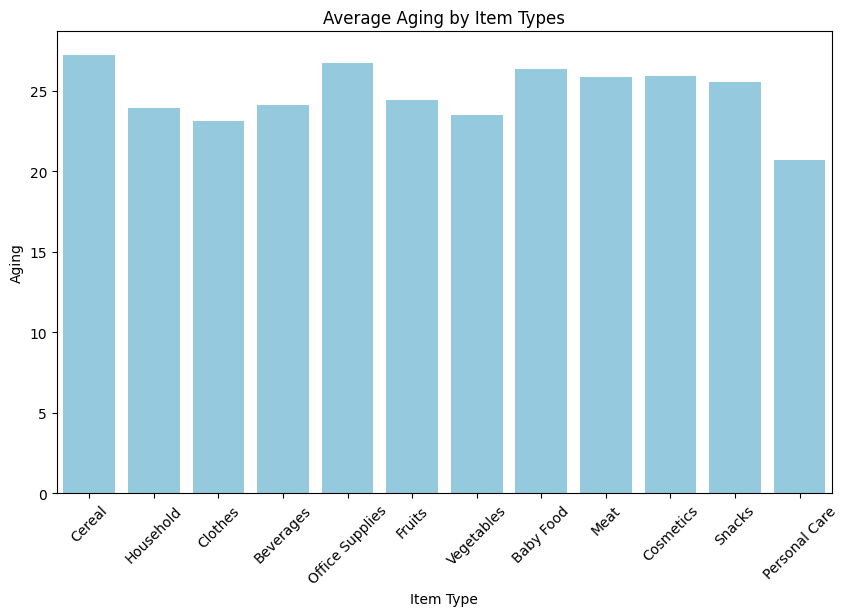

In [ ]:
# Aging by Item Types
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="item_type", y="aging", errorbar=("ci", False), color='skyblue')
plt.title("Average Aging by Item Types")
plt.xlabel("Item Type")
plt.ylabel("Aging")
plt.xticks(rotation=45)
plt.show()

Середня вартість доставки не залежить від категорії товару. Адже, у всіх категорії середня тривалість доставки близько **25 днів**.

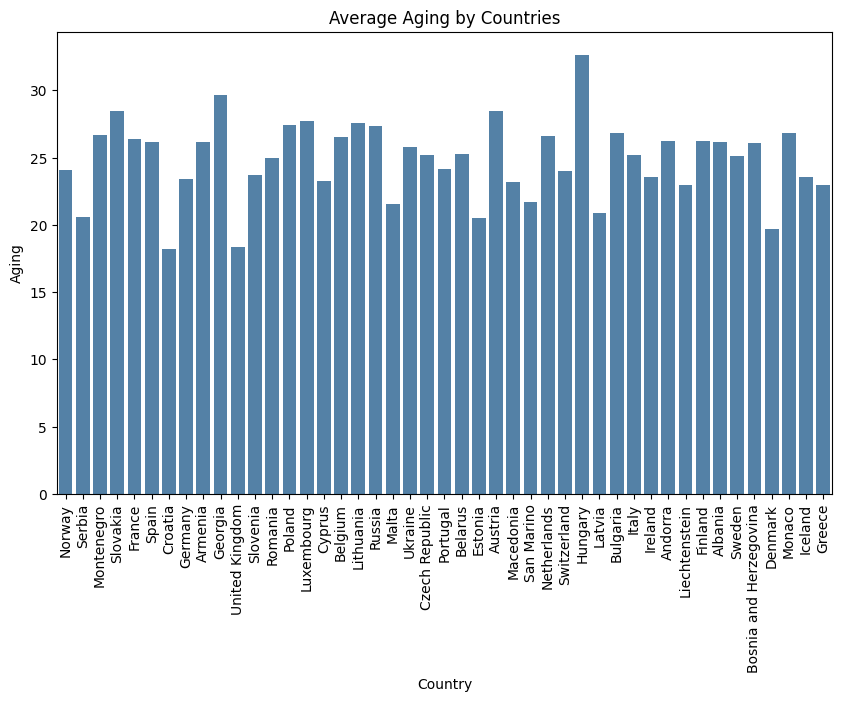

In [ ]:
# Aging by Countries
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="country", y="aging", errorbar=("ci", False), color='steelblue')
plt.title("Average Aging by Countries")
plt.xlabel("Country")
plt.ylabel("Aging")
plt.xticks(rotation=90)
plt.show()

Найбільший середній час доставки має Hungary, найбільший - Croatia та United Kingdom.

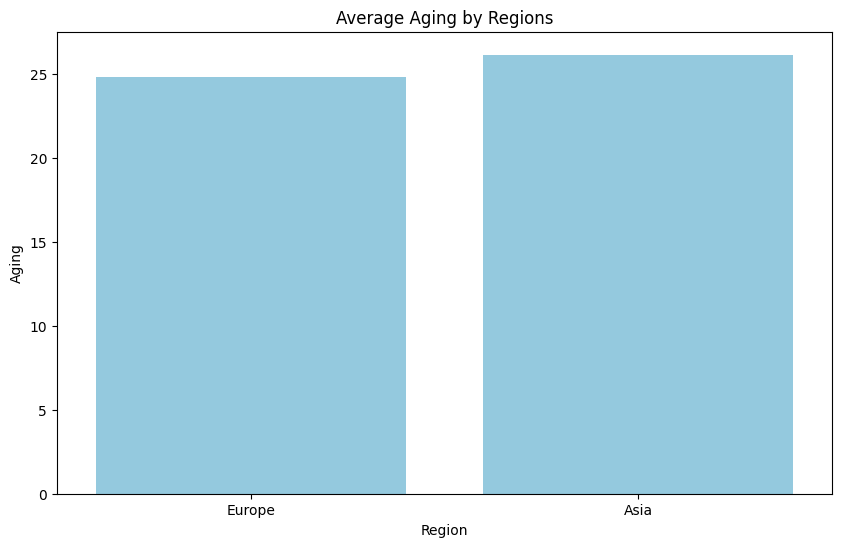

In [ ]:
# Aging by Regions
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="region", y="aging", errorbar=("ci", False), color='skyblue')
plt.title("Average Aging by Regions")
plt.xlabel("Region")
plt.ylabel("Aging")
plt.show()

Середня вартість доставки практично однакова для Азії та Європи, друга трішки швидша.

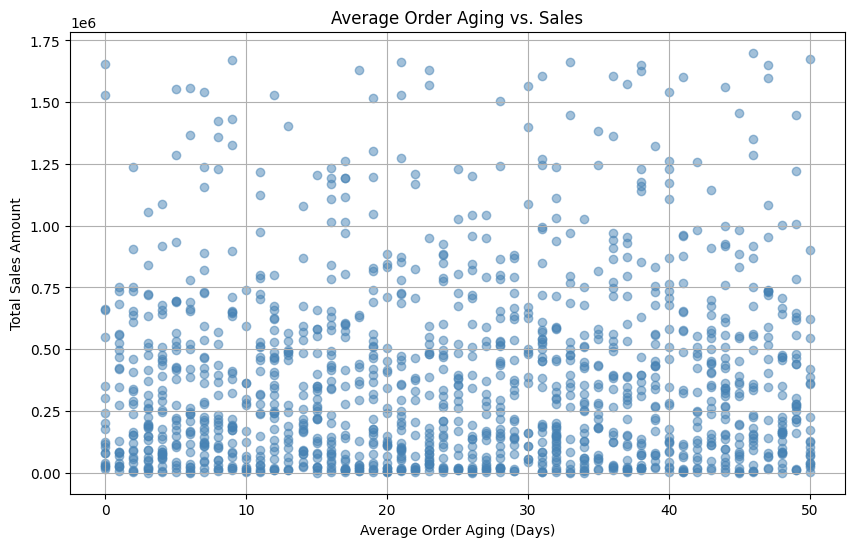

In [ ]:
# Create a scatter plot to visualize the relationship between aging and sales
plt.figure(figsize=(10, 6))
plt.scatter(df["aging"], df["profit"], alpha=0.5, color="steelblue")
plt.xlabel("Average Order Aging (Days)")
plt.ylabel("Total Sales Amount")
plt.title("Average Order Aging vs. Sales")
plt.grid(True)
plt.show()

In [ ]:
# Group by 'item_type' and the date column, and calculate the sum of 'units_sold' for each group
df["order_month_year"] = df["order_date"].dt.strftime('%Y-%m')
region_orders = df.groupby(["region", "order_month_year"])["units_sold"].sum().reset_index()
region_orders.head()

,region,order_month_year,units_sold
0,Asia,2010-01,11976.0
1,Asia,2010-02,13399.0
2,Asia,2010-05,8878.0
3,Asia,2010-10,9875.0
4,Asia,2010-12,12373.0


In [ ]:
# Create time series plots by region
regions = region_orders["region"].unique()
print(regions)

['Asia' 'Europe']


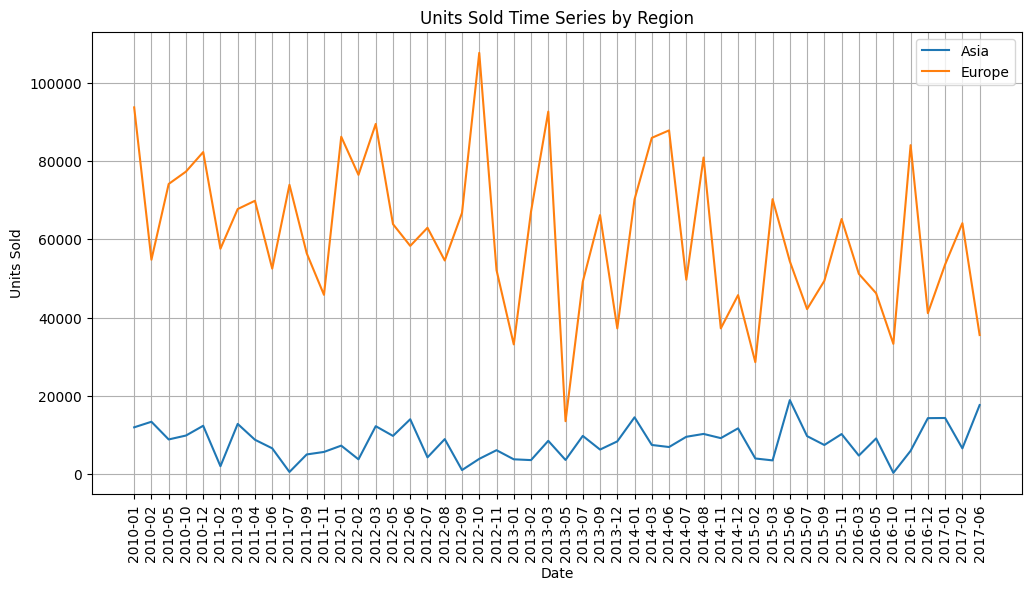

In [ ]:
# Find common months for Europe and Asia
europe_months = df[df["region"] == "Europe"]["order_month_year"].unique()
asia_months = df[df["region"] == "Asia"]["order_month_year"].unique()
common_months = list(set(europe_months) & set(asia_months))
common_months.sort()

# Filtering data by common months
filtered_df = df[df["order_month_year"].isin(common_months)]

# Grouped data
region_orders_sold = (
    filtered_df.groupby(["region", "order_month_year"])["units_sold"].sum().reset_index().sort_values(by="order_month_year")
)

# Create plot
plt.figure(figsize=(12, 6))
for region in regions:
    region_data = region_orders_sold[region_orders_sold["region"] == region]
    plt.plot(region_data["order_month_year"], region_data["units_sold"], label=region)

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Units Sold Time Series by Region")
plt.legend()
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

У Азії значно менший рівень протажів та вони є більш стабільними ніж в Європі. У Європі бачимо різкі зростання в жовтні 2012, березні 2013, березень-червень 2014 та листопад 2011. Але відразу після зростань спостерігаються різні спади. Тому тут простежуються певні коливання, але як такої сезонності не видно.

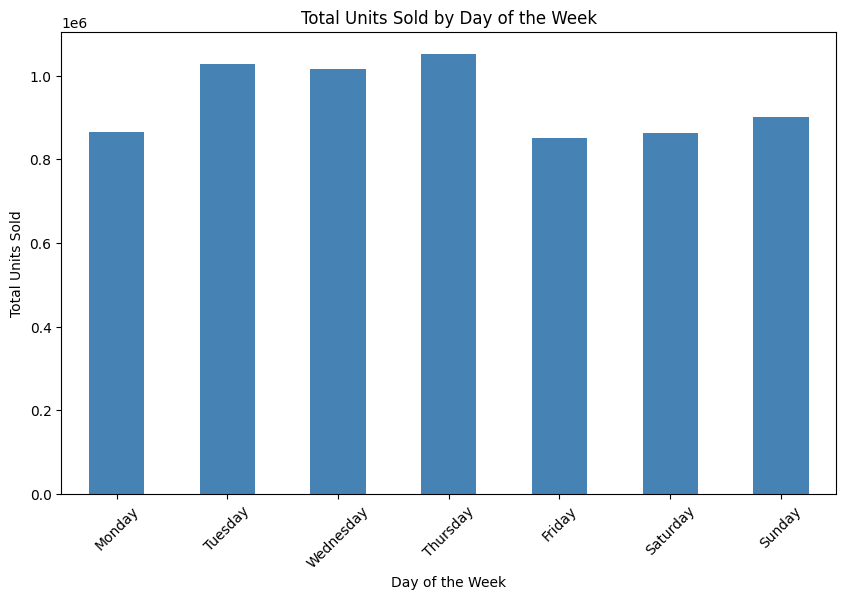

In [ ]:
# Total Units Sold by day of the week
df["day_of_week"]=df["order_date"].dt.day_name()

day_of_week_sales = df.groupby("day_of_week")["units_sold"].sum()
day_of_week_sales.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
plt.figure(figsize=(10, 6))
day_of_week_sales.plot(
    kind="bar",
    xlabel="Day of the Week",
    ylabel="Total Units Sold",
    title="Total Units Sold by Day of the Week",
    color = "steelblue"
)
plt.xticks(rotation=45)
plt.show()

Найбільше продажів відбувається **з вівторка по четвер**, в інші дні трішки менше.

# Висновки та рекомендації

* **Categories:** Потрібно звернути увагу на товари, які приносять низькі прибутки: Fruits, Beverages, Personal Care.  
* **Regions:** У Азії в нас значно нижчі продажі, можливо варто їх збільшити.

* **Sale channels:** Канал продажу не впливає на наші прибутки.  
* **Day of week:** По дням тижня більші продажі у вівторок-четвер.  
* **Shipping by countries:** Є певні коливання часу доставки по країнах, напевно це повязано з різною відстанню доставки.  
* **Countries:** Також, є країни які приносять досить низькі прибутки (Monaco), варто їх детальніше дослідити чому так.